In [104]:
# Cell 1: import libraries, configure display, and set up module path
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")

# Ensure the project root is on sys.path so we can import scripts.data
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from scripts import data as data_module


In [105]:
# Cell 2: load cleaned Craigslist data and prepare dataframe with derived numeric features
csv_path = Path('..') / 'datasets' / 'craigslist_cleaned.csv'
if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found at expected path: {csv_path}")

# Use the same preparation logic as in scripts/data.py to keep features consistent
cfg = data_module.DataConfig(csv_path=str(csv_path))
df = data_module._prepare_frame(cfg)

print(f"Prepared dataframe shape: {df.shape}")
df.head()


Prepared dataframe shape: (331468, 25)


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,lat,long,posting_date,posting_date_formatted,quarter,posting_year,id,age_years,log_odometer,mileage_per_year
0,hudson valley,18997,2013,dodge,durango,excellent,6 cylinders,gas,96475,clean,automatic,4wd,suv,black,ny,42.598,-73.708,2021-04-04 07:00:00+00:00,2021-04-04 07:00:25,Y2021Q2,2021,0,12,11.477,8039.583
1,kenosha-racine,119,2013,dodge,dart,excellent,4 cylinders,gas,71800,not_available,automatic,not_available,sedan,not_available,wi,42.596,-87.879,2021-04-04 07:03:00+00:00,2021-04-04 07:03:15,Y2021Q2,2021,1,12,11.182,5983.333
2,richmond,18937,2011,not_available,forde350,not_available,missing,gas,40000,clean,automatic,not_available,not_available,not_available,va,33.821,-84.355,2021-04-04 07:08:00+00:00,2021-04-04 07:08:37,Y2021Q2,2021,2,14,10.597,2857.143
3,western slope,38900,2013,not_available,grand caravan,not_available,6 cylinders,not_available,19,clean,automatic,fwd,not_available,black,co,39.674,-104.999,2021-04-04 07:10:00+00:00,2021-04-04 07:10:45,Y2021Q2,2021,3,12,2.996,1.583
4,richmond,11750,2013,honda,civic lx,good,4 cylinders,gas,55000,clean,automatic,fwd,not_available,silver,va,37.523,-77.445,2021-04-04 07:20:00+00:00,2021-04-04 07:20:50,Y2021Q2,2021,4,12,10.915,4583.333


## Numeric OOD

In [106]:
# Cell 3: verify presence of key numeric features and inspect their basic statistics
numeric_cols = ['year', 'odometer', 'mileage_per_year']
missing = [c for c in numeric_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected numeric columns: {missing}")

df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])


,year,odometer,mileage_per_year
count,331468.000,331468.000,331468.000
mean,2011.776,91533.688,6880.853
std,7.150,63050.708,3957.618
min,1971.000,0.000,0.000
1%,1984.000,39.000,4.524
5%,1999.000,7486.000,1042.820
10%,2003.000,15471.000,1952.857
50%,2013.000,85548.000,6666.667
90%,2019.000,178000.000,11857.143
95%,2020.000,203000.000,13636.364


In [107]:
# Cell 4: compute and display quantiles used to define numeric tails
quantiles = {}
for col in numeric_cols:
    qs = df[col].quantile([0.05, 0.10, 0.90, 0.95])
    quantiles[col] = qs

quantile_df = pd.DataFrame(quantiles, index=[0.05, 0.10, 0.90, 0.95])
quantile_df.index.name = 'quantile'
quantile_df


,year,odometer,mileage_per_year
quantile,,,
0.050,1999.000,7486.000,1042.820
0.100,2003.000,15471.000,1952.857
0.900,2019.000,178000.000,11857.143
0.950,2020.000,203000.000,13636.364


In [108]:
# Cell 5: define tail OOD masks based on 5th and 95th percentiles and summarize their sizes
q = {col: df[col].quantile([0.05, 0.95]) for col in numeric_cols}

mask_mpy_high = df['mileage_per_year'] > q['mileage_per_year'].loc[0.95]
mask_odo_high = df['odometer'] > q['odometer'].loc[0.95]
mask_year_old = df['year'] < q['year'].loc[0.05]

mask_any_tail = mask_mpy_high | mask_odo_high | mask_year_old
mask_multi_tail = (mask_mpy_high.astype(int) + mask_odo_high.astype(int) + mask_year_old.astype(int)) >= 2

def _summ(mask, name):
    n = int(mask.sum())
    frac = n / len(df)
    print(f"{name}: {n} rows ({frac:.3%})")

_summ(mask_mpy_high, 'OOD_mpy_high')
_summ(mask_odo_high, 'OOD_odo_high')
_summ(mask_year_old, 'OOD_year_old')
_summ(mask_any_tail, 'OOD_any_tail (union)')
_summ(mask_multi_tail, 'OOD_multi_tail (>=2 tails)')


OOD_mpy_high: 16569 rows (4.999%)
OOD_odo_high: 16525 rows (4.985%)
OOD_year_old: 14214 rows (4.288%)
OOD_any_tail (union): 40490 rows (12.215%)
OOD_multi_tail (>=2 tails): 6818 rows (2.057%)


In [109]:
# Cell 6: compare numeric distributions between candidate ID core and union of tail OOD rows
id_mask = ~mask_any_tail

def describe_subset(mask, name):
    sub = df.loc[mask, numeric_cols]
    desc = sub.describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])
    desc.insert(0, 'subset', name)
    return desc

desc_id = describe_subset(id_mask, 'ID_candidate')
desc_ood_any = describe_subset(mask_any_tail, 'OOD_any_tail')

pd.concat([desc_id, desc_ood_any])


,subset,year,odometer,mileage_per_year
count,ID_candidate,290978.000,290978.000,290978.000
mean,ID_candidate,2013.017,80364.626,6354.570
std,ID_candidate,5.102,53123.767,3231.922
min,ID_candidate,1999.000,0.000,0.000
1%,ID_candidate,2000.000,27.000,4.200
5%,ID_candidate,2003.000,6882.250,1050.400
10%,ID_candidate,2005.000,14113.000,1960.000
50%,ID_candidate,2014.000,76435.000,6400.000
90%,ID_candidate,2019.000,156923.000,10679.735
95%,ID_candidate,2020.000,174919.600,11738.168


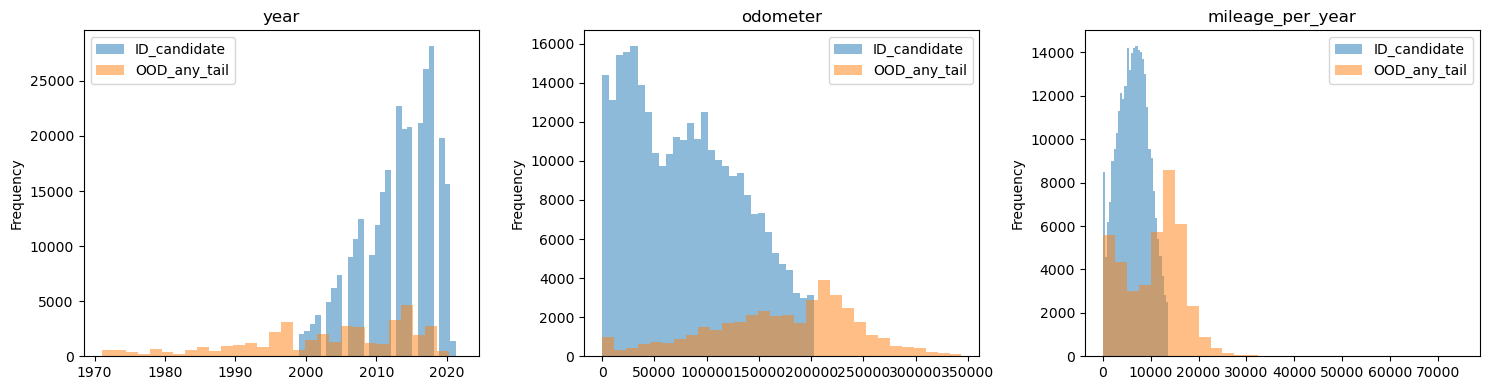

In [110]:
# Cell 7: plot histograms for key numeric features comparing ID_candidate vs OOD_any_tail
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    df.loc[id_mask, col].plot(kind='hist', bins=30, alpha=0.5, label='ID_candidate', ax=ax)
    df.loc[mask_any_tail, col].plot(kind='hist', bins=30, alpha=0.5, label='OOD_any_tail', ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()


In [111]:
# Cell 8: summarize numeric distributions for each individual tail OOD set
summaries = []
summaries.append(describe_subset(mask_mpy_high, 'OOD_mpy_high'))
summaries.append(describe_subset(mask_odo_high, 'OOD_odo_high'))
summaries.append(describe_subset(mask_year_old, 'OOD_year_old'))
display(pd.concat(summaries))


,subset,year,odometer,mileage_per_year
count,OOD_mpy_high,16569.000,16569.000,16569.000
mean,OOD_mpy_high,2013.720,182037.961,16357.179
std,OOD_mpy_high,3.263,51822.126,3027.269
min,OOD_mpy_high,2000.000,56000.000,13636.417
1%,OOD_mpy_high,2004.000,85548.000,13666.667
5%,OOD_mpy_high,2007.000,109887.400,13770.693
10%,OOD_mpy_high,2009.000,121449.000,13911.500
50%,OOD_mpy_high,2014.000,175711.000,15436.889
90%,OOD_mpy_high,2017.000,255812.000,19833.417
95%,OOD_mpy_high,2018.000,283331.600,21912.735


In [112]:
# Cell 9: examine overlap patterns between the three tail OOD masks
tail_membership = pd.DataFrame({
    'mpy_high': mask_mpy_high,
    'odo_high': mask_odo_high,
    'year_old': mask_year_old,
})
tail_membership['n_tails'] = tail_membership[['mpy_high', 'odo_high', 'year_old']].sum(axis=1)

pattern_counts = tail_membership.value_counts(subset=['mpy_high', 'odo_high', 'year_old']).rename('count').reset_index()
pattern_counts['fraction'] = pattern_counts['count'] / len(df)
display(pattern_counts.sort_values('count', ascending=False))


,mpy_high,odo_high,year_old,count,fraction
0,False,False,False,290978,0.878
1,False,False,True,12308,0.037
2,True,False,False,11657,0.035
3,False,True,False,9707,0.029
4,True,True,False,4912,0.015
5,False,True,True,1906,0.006


In [113]:
# Cell 10: compare top manufacturer, type, and state distributions between ID and each tail OOD set
cat_cols = ['manufacturer', 'type', 'state']

def top_counts(mask, subset_name, col, k=10):
    vc = df.loc[mask, col].value_counts(dropna=False).head(k)
    out = vc.to_frame(name='count')
    out['fraction'] = out['count'] / mask.sum()
    out['subset'] = subset_name
    out['column'] = col
    return out.reset_index().rename(columns={'index': col})

rows = []
for col in cat_cols:
    rows.append(top_counts(id_mask, 'ID_candidate', col))
    rows.append(top_counts(mask_mpy_high, 'OOD_mpy_high', col))
    rows.append(top_counts(mask_odo_high, 'OOD_odo_high', col))
    rows.append(top_counts(mask_year_old, 'OOD_year_old', col))

cat_summary = pd.concat(rows, ignore_index=True)
display(cat_summary)


,manufacturer,count,fraction,subset,column,type,state
0,ford,44403,0.153,ID_candidate,manufacturer,NaN,NaN
1,chevrolet,34415,0.118,ID_candidate,manufacturer,NaN,NaN
2,toyota,23467,0.081,ID_candidate,manufacturer,NaN,NaN
3,honda,15078,0.052,ID_candidate,manufacturer,NaN,NaN
4,nissan,13558,0.047,ID_candidate,manufacturer,NaN,NaN
5,jeep,13253,0.046,ID_candidate,manufacturer,NaN,NaN
6,bmw,11667,0.040,ID_candidate,manufacturer,NaN,NaN
7,gmc,11056,0.038,ID_candidate,manufacturer,NaN,NaN
8,ram,10952,0.038,ID_candidate,manufacturer,NaN,NaN
9,dodge,8908,0.031,ID_candidate,manufacturer,NaN,NaN


In [114]:
# Cell 11: display random examples from each tail OOD set for qualitative inspection
n_show = 10
cols_to_show = ['region', 'price', 'year', 'manufacturer', 'model', 'odometer',
                'mileage_per_year', 'condition', 'type', 'state']

for name, mask in [
    ('OOD_mpy_high', mask_mpy_high),
    ('OOD_odo_high', mask_odo_high),
    ('OOD_year_old', mask_year_old),
]:
    n_rows = int(mask.sum())
    print(f"\n=== {name} examples (n={n_rows}) ===")
    if n_rows == 0:
        print("No rows in this subset.")
        continue
    display(df.loc[mask, cols_to_show].sample(min(n_show, n_rows), random_state=1))



=== OOD_mpy_high examples (n=16569) ===


,region,price,year,manufacturer,model,odometer,mileage_per_year,condition,type,state
136760,austin,22790,2017,ford,f250 xlreg cab 8 ft box,119881,14985.125,excellent,truck,tx
289874,flint,34500,2015,ford,f-350 super duty,190000,19000.000,not_available,not_available,mi
6402,missoula,54999,2017,not_available,2017,119000,14875.000,not_available,not_available,mt
136876,little rock,22300,2017,ford,transit 150,113617,14202.125,excellent,van,ar
255041,fredericksburg,6000,2011,honda,pilot lx,199000,14214.286,excellent,suv,va
193659,jersey shore,7450,2009,acura,mdx,226250,14140.625,excellent,suv,nj
184520,wichita,13798,2018,jeep,cherokee,105429,15061.286,not_available,not_available,ks
7057,bakersfield,26995,2017,ford,f-150 xlt,110130,13766.250,excellent,truck,ca
129483,chillicothe,24995,2015,chevrolet,silverado 1500,180293,18029.300,excellent,pickup,oh
281830,dubuque,3650,2010,toyota,sienna le,219000,14600.000,excellent,mini-van,ia



=== OOD_odo_high examples (n=16525) ===


,region,price,year,manufacturer,model,odometer,mileage_per_year,condition,type,state
112291,colorado springs,2595,2006,volkswagen,beetle tdi,208998,10999.895,not_available,hatchback,co
52396,modesto,20000,2006,ford,f350 super duty,220000,11578.947,not_available,not_available,ca
277807,indianapolis,6995,2010,dodge,charger,214109,14273.933,not_available,not_available,in
95660,cincinnati,5300,1999,toyota,4runner limited,234000,9000.000,good,suv,oh
202108,fresno / madera,9500,2003,gmc,yukon sle,252790,11490.455,good,suv,ca
17094,billings,4995,2006,toyota,sienna ce 7 passenger,216713,11405.947,not_available,van,mt
241274,dayton / springfield,3500,2009,pontiac,vibe,218000,13625.000,good,wagon,oh
122493,albuquerque,4995,2011,subaru,outback,222301,15878.643,good,wagon,nm
258928,humboldt county,2000,1997,dodge,dakota,261479,9338.536,fair,truck,ca
154971,western massachusetts,3295,2007,nissan,xterra,224000,12444.444,not_available,not_available,ma



=== OOD_year_old examples (n=14214) ===


,region,price,year,manufacturer,model,odometer,mileage_per_year,condition,type,state
239910,new hampshire,3995,1980,not_available,seagrave,37047,823.267,not_available,not_available,nh
269073,rochester,2000,1998,chevrolet,silverado 1500,215000,7962.963,not_available,pickup,ny
267601,colorado springs,3500,1991,chevrolet,cavalier,91300,2685.294,excellent,wagon,co
220960,inland empire,7500,1989,chevrolet,corvette,140000,3888.889,good,convertible,ca
330002,spokane / coeur d'alene,4000,1996,gmc,yukon slt,175000,6034.483,good,suv,wa
147422,north jersey,12800,1971,chevrolet,el camino,90487,1675.685,good,not_available,nj
146945,san antonio,3200,1997,ram,1500,187000,6678.571,not_available,not_available,tx
212881,reno / tahoe,5500,1980,chevrolet,blazer,73083,1624.067,fair,truck,ca
270158,des moines,1200,1995,not_available,740il,117000,3900.000,fair,sedan,ia
141257,jackson,19900,1998,chevrolet,corvette convertible,19000,703.704,not_available,not_available,tn


## Numeric-Tail OOD Summary (from `ood_tails_numeric.ipynb`)

### 1. Dataset and features

- Source: `datasets/craigslist_cleaned.csv` (331,468 rows), used-car listings from ~Q2 2021.
- Core numeric features considered:
  - `year` – model year of the vehicle.
  - `odometer` – total mileage recorded.
  - `mileage_per_year` – derived as odometer / age (years), matching `scripts/data.py`.
- High-level distribution (full dataset):
  - `year`: mean 2011.8, median 2013, 5th–95th ≈ 1999–2020 (min 1971, max 2022).
  - `odometer`: mean 91.5k, median 85.5k, 5th–95th ≈ 7.5k–203k (min 0, max 343.9k).
  - `mileage_per_year`: mean 6.9k, median 6.7k, 5th–95th ≈ 1.0k–13.6k (min 0, max 75k).

### 2. Tail-based OOD definitions

We define three single-feature numeric-tail OOD sets using 5th/95th percentiles of the full dataset:

- **OOD_mpy_high** (high yearly mileage)
  - Definition: `mileage_per_year > 95th percentile ≈ 13,636 miles/year`.
  - Intuition: relatively modern cars driven very heavily each year (e.g., fleets, commuters, work trucks).

- **OOD_odo_high** (high lifetime mileage)
  - Definition: `odometer > 95th percentile ≈ 203,000 miles`.
  - Intuition: vehicles with extreme lifetime mileage, regardless of age-normalized usage.

- **OOD_year_old** (pre-1999 “vintage/older” vehicles)
  - Definition: `year < 5th percentile = 1999`.
  - Intuition: older/vintage cars (1971–1998) present in 2021 listings, treated as out-of-domain for this project.

We also define:

- **OOD_any_tail**: union of the three tails (row is in at least one of the above).
- **OOD_multi_tail**: rows that belong to at least two tails (`n_tails ≥ 2`).

The complement of `OOD_any_tail` is the **ID_candidate** set used in this notebook for comparison.

### 3. Sizes and overlaps

Let `N = 331,468` be total rows.

**Single tails and unions**

| Subset             | Definition                               | Rows (n) | % of data |
|--------------------|------------------------------------------|---------:|----------:|
| ID_candidate       | not in any numeric-tail OOD              | 290,978  | 87.8%     |
| OOD_mpy_high       | `mileage_per_year > 13,636`              | 16,569   | 5.0%      |
| OOD_odo_high       | `odometer > 203,000`                     | 16,525   | 5.0%      |
| OOD_year_old       | `year < 1999`                            | 14,214   | 4.3%      |
| OOD_any_tail       | in any of the three tails                | 40,490   | 12.2%     |
| OOD_multi_tail     | in ≥2 of the three tails                 | 6,818    | 2.1%      |

**Overlap pattern (approximate)**

| mpy_high | odo_high | year_old | Rows (n) | % of data | Interpretation                       |
|---------:|---------:|---------:|---------:|----------:|--------------------------------------|
| False    | False    | False    | 290,978  | 87.8%     | ID_candidate                         |
| False    | False    | True     | 12,308   | 3.7%      | only OOD_year_old                    |
| True     | False    | False    | 11,657   | 3.5%      | only OOD_mpy_high                    |
| False    | True     | False    | 9,707    | 2.9%      | only OOD_odo_high                    |
| True     | True     | False    | 4,912    | 1.5%      | high mpy **and** high odometer       |
| False    | True     | True     | 1,906    | 0.6%      | high odometer **and** very old year  |
| Others   | (triple intersection etc.)    | small      | <0.1%     | part of OOD_multi_tail               |

### 4. Distribution shifts vs ID_candidate

**ID_candidate vs OOD_any_tail (summary)**

- `ID_candidate` (n ≈ 291k, 87.8%):
  - `year`: median 2014; 5th–95th ≈ 2003–2020.
  - `odometer`: median ≈ 76k; 5th–95th ≈ 6.9k–174.9k.
  - `mileage_per_year`: median ≈ 6,400; 5th–95th ≈ 1,050–11,738.
- `OOD_any_tail` (n ≈ 40.5k, 12.2%):
  - `year`: median 2005; 5th–95th ≈ 1979–2017.
  - `odometer`: median ≈ 181k; 5th–95th ≈ 40k–274.8k.
  - `mileage_per_year`: median ≈ 11,720; 5th–95th ≈ 994–19,245.

Histograms show that:

- `OOD_any_tail` is clearly shifted toward:
  - Older vehicles (left-shifted `year`), and
  - Much higher `odometer` and `mileage_per_year` (right-shifted).
- ID_candidate occupies the “bulk” region in all three numerics.

**Per-tail distributions**

- **OOD_mpy_high** (n = 16,569; high yearly mileage)
  - `year`: median 2014; 10th–90th ≈ 2009–2017 (relatively new cars).
  - `odometer`: median ≈ 176k; 5th–95th ≈ 110k–283k.
  - `mileage_per_year`: median ≈ 15.4k; 5th–95th ≈ 13.8k–21.9k.
  - Interpretation: newer vehicles heavily driven each year, often with high total mileage.

- **OOD_odo_high** (n = 16,525; high lifetime mileage)
  - `year`: median 2005; 10th–90th ≈ 1998–2012 (noticeably older than ID).
  - `odometer`: median ≈ 229k; 5th–95th ≈ 205k–300k.
  - `mileage_per_year`: median ≈ 11.9k; 5th–95th ≈ 7.7k–20.3k.
  - Interpretation: high-mileage “workhorse” vehicles, moderate to high annual usage over many years.

- **OOD_year_old** (n = 14,214; pre-1999)
  - `year`: range 1971–1998; median 1992; 90th ≈ 1998.
  - `odometer`: median ≈ 111k; 5th–95th ≈ 3.3k–249.9k.
  - `mileage_per_year`: median ≈ 3.3k; 90th–95th ≈ 7.3k–8.3k.
  - Interpretation: older/vintage cars with moderate annual use; not necessarily extreme total mileage but clearly outside the modern age range.

### 5. Category composition (manufacturer, type, state)

Overall, the numeric-tail OOD sets remain dominated by **mainstream brands and states**; they are not just “some tiny exotic niche”. However, each tail has its own flavor:

**Manufacturers (top few; fraction within subset)**

- **ID_candidate**:
  - ford 15.3%, chevrolet 11.8%, toyota 8.1%, honda 5.2%, nissan 4.7%, jeep 4.6%, bmw 4.0%, gmc 3.8%, ram 3.8%, dodge 3.1%.
- **OOD_mpy_high**:
  - ford 30.3%, chevrolet 17.6%, ram 9.5%, toyota 7.8%, gmc 5.9%, not_available 4.4%, honda 3.9%, nissan 3.6%, dodge 3.1%, subaru 2.1%.
- **OOD_odo_high**:
  - ford 21.4%, toyota 15.4%, chevrolet 15.2%, honda 8.4%, gmc 5.7%, not_available 5.5%, ram 5.2%, nissan 2.7%, jeep 2.7%, subaru 2.2%.
- **OOD_year_old**:
  - chevrolet 20.5%, ford 17.9%, not_available 11.3%, toyota 7.3%, jeep 6.4%, gmc 3.7%, mercedes-benz 3.6%, honda 2.9%, dodge 2.4%, volkswagen 2.4%.

**Vehicle type (top few; fraction within subset)**

- **ID_candidate**:
  - not_available 24.8%, sedan 22.1%, suv 18.8%, pickup 10.5%, truck 6.8%, hatchback 4.7%, coupe 4.7%, wagon 2.7%, van 1.9%, convertible 1.7%.
- **OOD_mpy_high**:
  - not_available 32.7%, pickup 16.8%, truck 16.5%, suv 12.8%, sedan 10.4%, van 4.6%, wagon 1.9%, mini-van 1.9%, hatchback 1.5%, coupe 0.5%.
- **OOD_odo_high**:
  - not_available 33.0%, suv 18.6%, truck 14.3%, pickup 12.1%, sedan 10.9%, van 2.6%, mini-van 2.3%, hatchback 1.9%, wagon 1.7%, coupe 1.7%.
- **OOD_year_old**:
  - not_available 37.4%, truck 11.2%, coupe 10.6%, sedan 9.4%, pickup 8.3%, suv 7.8%, convertible 7.8%, van 2.3%, hatchback 1.8%, offroad 1.3%.

**States (top few; fraction within subset)**

- **ID_candidate**:
  - CA 11.4%, FL 6.8%, TX 5.3%, NY 4.9%, MI 4.3%, OH 4.2%, OR 3.5%, PA 3.4%, WA 3.2%, NC 3.2%.
- **OOD_mpy_high**:
  - CA 8.0%, TX 7.9%, MI 7.9%, FL 7.3%, NC 4.6%, OH 4.2%, TN 4.0%, WI 2.8%, MN 2.8%, NY 2.7%.
- **OOD_odo_high**:
  - CA 10.7%, MI 6.5%, FL 5.8%, TX 5.4%, OR 4.6%, NC 4.2%, OH 4.1%, CO 3.8%, MN 3.1%, WA 3.1%.
- **OOD_year_old**:
  - CA 12.7%, FL 6.1%, TX 4.6%, OR 4.4%, NY 4.1%, CO 4.0%, NC 4.0%, OH 3.9%, WA 3.6%, PA 3.4%.

Conclusion: all tail OOD sets are still geographically broad and dominated by mainstream brands and types. The OOD signal is primarily in the numeric features, not in a single unusual location or niche manufacturer.

### 6. Qualitative inspection

Random samples from each tail OOD set show:

- **OOD_mpy_high**:
  - Recent (often 2015–2018) trucks, vans, SUVs, and sedans with odometer values well over 110k and annual mileage > 13–15k.
- **OOD_odo_high**:
  - Older cars (late 90s to 2010s) with odometer in the 200k–300k range across varied types (sedans, SUVs, wagons, trucks).
- **OOD_year_old**:
  - Vehicles from the 1970s–1990s, including pickups, coupes, convertibles, and trucks, many with moderate annual mileage but clearly outside the modern age range.

Listings look plausible (no widespread obviously impossible values), supporting their use as realistic but out-of-domain evaluation slices.

### 7. Intended use

- These tail-based OOD sets are **not** yet used to modify the training data.
- Final plan (later step):
  - ID_final will be defined by removing the union of all chosen OOD families (numeric tails, rare categories, and geographic OOD) from the current cleaned dataset.
  - Numeric-tail OOD sets will be saved as separate CSVs (e.g., `craigslist_ood_mpy_high.csv`, `craigslist_ood_odo_high.csv`, `craigslist_ood_year_old.csv`, plus optionally `craigslist_ood_multi_tail.csv`) for evaluating epistemic uncertainty and OOD detection.

In summary, the analyses in this notebook identify three principled numeric-tail OOD families—high yearly mileage, extreme lifetime mileage, and pre‑1999 “vintage” vehicles—that together cover about 12% of the cleaned dataset while leaving a large, well‑behaved ID core. Each OOD slice represents a clear, interpretable covariate shift in features the model actually uses, yet remains grounded in realistic used‑car listings and a broadly similar mix of manufacturers, types, and states. These properties make the tail‑based OOD sets suitable as building blocks for a comprehensive OOD evaluation suite: they can be combined with future rare‑category and geographic OOD definitions to stress‑test epistemic uncertainty without relying on artificial corruptions or degenerate edge cases, and they support a defensible narrative that distinguishes the model’s intended operating domain from well‑characterized out‑of‑domain regimes.


## Rare OOD

,manufacturer,count,fraction,cum_fraction
0,ford,53791,0.162,0.162
1,chevrolet,41708,0.126,0.288
2,toyota,27418,0.083,0.371
3,honda,17099,0.052,0.422
4,jeep,14685,0.044,0.467
5,nissan,14658,0.044,0.511
6,ram,13250,0.040,0.551
7,gmc,13128,0.040,0.591
8,bmw,12049,0.036,0.627
9,not_available,11624,0.035,0.662


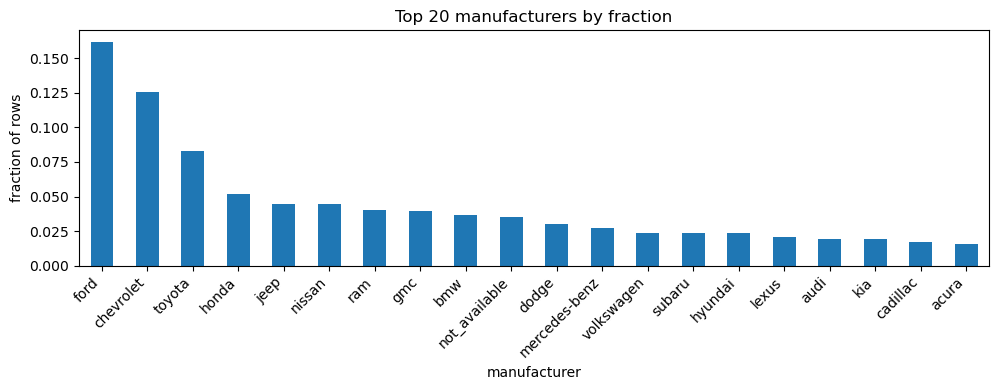

In [115]:
# Cell 12: compute manufacturer frequency table and cumulative coverage
man_counts = df['manufacturer'].value_counts(dropna=False)
man_table = man_counts.to_frame(name='count').reset_index().rename(columns={'index': 'manufacturer'})
man_table['fraction'] = man_table['count'] / len(df)
man_table['cum_fraction'] = man_table['fraction'].cumsum()
display(man_table.head(20))

# Plot histogram-style bar chart for top manufacturers by fraction
top_n_man = 20
fig, ax = plt.subplots(figsize=(10, 4))
man_table.head(top_n_man).plot(kind='bar', x='manufacturer', y='fraction', ax=ax, legend=False)
ax.set_ylabel('fraction of rows')
ax.set_title(f'Top {top_n_man} manufacturers by fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [116]:
# Cell 13: evaluate candidate coverage thresholds for rare manufacturers
coverage_targets_man = [0.90, 0.95]
rows = []

for cov in coverage_targets_man:
    common_man = man_table[man_table['cum_fraction'] <= cov]['manufacturer']
    rare_man = man_table[man_table['cum_fraction'] > cov]['manufacturer']
    rare_non_placeholder = [m for m in rare_man if str(m).lower() != 'not_available']

    mask_rare_all = df['manufacturer'].isin(rare_non_placeholder)
    mask_rare_numeric_id = mask_rare_all & id_mask

    rows.append({
        'coverage_target': cov,
        'n_common_manufacturers': int(common_man.nunique()),
        'n_rare_manufacturers': len(rare_non_placeholder),
        'rows_rare_all': int(mask_rare_all.sum()),
        'frac_rare_all': mask_rare_all.mean(),
        'rows_rare_numeric_id': int(mask_rare_numeric_id.sum()),
        'frac_rare_numeric_id': mask_rare_numeric_id.mean(),
    })

pd.DataFrame(rows)


,coverage_target,n_common_manufacturers,n_rare_manufacturers,rows_rare_all,frac_rare_all,rows_rare_numeric_id,frac_rare_numeric_id
0,0.900,21,21,34439,0.104,31766,0.096
1,0.950,25,17,17855,0.054,16302,0.049


In [117]:
# Cell 14: define rare manufacturer OOD mask for a chosen coverage threshold
coverage_target_man = 0.90  # adjust to 0.95 if you prefer a smaller rare set

common_man = man_table[man_table['cum_fraction'] <= coverage_target_man]['manufacturer']
rare_man = man_table[man_table['cum_fraction'] > coverage_target_man]['manufacturer']
rare_man_non_placeholder = [m for m in rare_man if str(m).lower() != 'not_available']

mask_ood_rare_man_all = df['manufacturer'].isin(rare_man_non_placeholder)
mask_ood_rare_man = mask_ood_rare_man_all & id_mask  # restrict to numeric ID core
mask_id_no_rare_man = id_mask & ~mask_ood_rare_man_all

_summ(mask_ood_rare_man_all, 'OOD_rare_manufacturers_all (no numeric filter)')
_summ(mask_ood_rare_man, 'OOD_rare_manufacturers (within numeric ID core)')
_summ(mask_id_no_rare_man, 'ID_no_numeric_tails_common_manufacturers')

print('\nSample of rare manufacturer labels:')
print(sorted(rare_man_non_placeholder)[:20])


OOD_rare_manufacturers_all (no numeric filter): 34439 rows (10.390%)
OOD_rare_manufacturers (within numeric ID core): 31766 rows (9.583%)
ID_no_numeric_tails_common_manufacturers: 259212 rows (78.201%)

Sample of rare manufacturer labels:
['alfa-romeo', 'aston-martin', 'buick', 'datsun', 'ferrari', 'fiat', 'harley-davidson', 'infiniti', 'jaguar', 'land rover', 'lincoln', 'mazda', 'mercury', 'mini', 'mitsubishi', 'pontiac', 'porsche', 'rover', 'saturn', 'tesla']


,subset,year,odometer,mileage_per_year
count,ID_no_numeric_tails_common_manufacturers,259212.000,259212.000,259212.000
mean,ID_no_numeric_tails_common_manufacturers,2012.984,81685.183,6473.556
std,ID_no_numeric_tails_common_manufacturers,5.057,52914.907,3228.061
min,ID_no_numeric_tails_common_manufacturers,1999.000,0.000,0.000
1%,ID_no_numeric_tails_common_manufacturers,2000.000,23.000,3.699
5%,ID_no_numeric_tails_common_manufacturers,2003.000,7399.550,1128.000
10%,ID_no_numeric_tails_common_manufacturers,2005.000,15000.000,2050.333
50%,ID_no_numeric_tails_common_manufacturers,2014.000,78379.000,6555.556
90%,ID_no_numeric_tails_common_manufacturers,2019.000,157700.000,10769.990
95%,ID_no_numeric_tails_common_manufacturers,2020.000,175000.000,11818.182


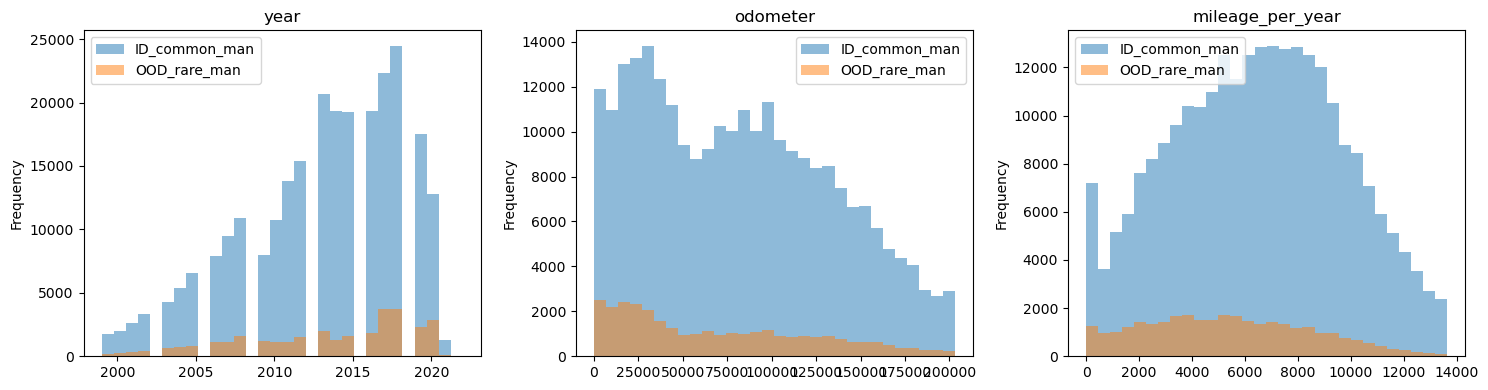

In [118]:
# Cell 15: compare numeric distributions for rare manufacturers vs ID numeric core
desc_id_no_rare_man = describe_subset(mask_id_no_rare_man, 'ID_no_numeric_tails_common_manufacturers')
desc_rare_man = describe_subset(mask_ood_rare_man, 'OOD_rare_manufacturers')
display(pd.concat([desc_id_no_rare_man, desc_rare_man]))

# Plot histograms for key numeric features comparing ID vs rare manufacturers
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    df.loc[mask_id_no_rare_man, col].plot(kind='hist', bins=30, alpha=0.5,
                                          label='ID_common_man', ax=ax)
    df.loc[mask_ood_rare_man, col].plot(kind='hist', bins=30, alpha=0.5,
                                        label='OOD_rare_man', ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()


In [119]:
# Cell 16: inspect manufacturer, type, and state mix for rare manufacturer OOD
rows_rare = []
for col in ['manufacturer', 'type', 'state']:
    rows_rare.append(top_counts(mask_id_no_rare_man, 'ID_no_numeric_tails_common_manufacturers', col))
    rows_rare.append(top_counts(mask_ood_rare_man, 'OOD_rare_manufacturers', col))
cat_summary_rare_man = pd.concat(rows_rare, ignore_index=True)
display(cat_summary_rare_man)


,manufacturer,count,fraction,subset,column,type,state
0,ford,44403,0.171,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
1,chevrolet,34415,0.133,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
2,toyota,23467,0.091,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
3,honda,15078,0.058,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
4,nissan,13558,0.052,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
5,jeep,13253,0.051,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
6,bmw,11667,0.045,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
7,gmc,11056,0.043,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
8,ram,10952,0.042,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN
9,dodge,8908,0.034,ID_no_numeric_tails_common_manufacturers,manufacturer,NaN,NaN


In [120]:
# Cell 17: show random examples from rare manufacturer OOD set for qualitative inspection
n_rows_rare_man = int(mask_ood_rare_man.sum())
print(f"Rare manufacturer OOD rows (within numeric ID core): n={n_rows_rare_man}")
if n_rows_rare_man > 0:
    cols_to_show = ['region', 'price', 'year', 'manufacturer', 'model', 'odometer',
                    'mileage_per_year', 'condition', 'type', 'state']
    display(df.loc[mask_ood_rare_man, cols_to_show].sample(min(10, n_rows_rare_man), random_state=1))


Rare manufacturer OOD rows (within numeric ID core): n=31766


,region,price,year,manufacturer,model,odometer,mileage_per_year,condition,type,state
9589,winchester,41990,2019,lincoln,continental reserve,9345,1557.500,good,sedan,va
179067,brainerd,5490,2008,buick,lacrosse cxs,162177,9539.824,not_available,sedan,mn
325029,yuba-sutter,17999,2012,porsche,cayenne,126523,9732.538,excellent,suv,ca
20256,monroe,7995,2011,lincoln,mkt,136681,9762.929,not_available,not_available,mi
39262,hartford,23990,2018,mitsubishi,outlander phev sel,28215,4030.714,good,suv,ct
51791,pittsburgh,35990,2020,lincoln,corsair sport utility 4d,8878,1775.600,good,suv,pa
323854,pensacola,2700,2009,infiniti,g37x,9999,624.938,good,not_available,fl
307724,los angeles,16240,2016,volvo,v60,57386,6376.222,not_available,wagon,ca
178812,albuquerque,7500,2011,mazda,6,54000,3857.143,like new,sedan,nm
36133,columbus,3999,2011,mercury,milan,106000,7571.429,good,sedan,oh


## Geographic OOD

State distribution on full dataset (top 20):


,state,count,fraction,cum_fraction
0,ca,37529,0.113,0.113
1,fl,22404,0.068,0.181
2,tx,17921,0.054,0.235
3,ny,15503,0.047,0.282
4,mi,14636,0.044,0.326
5,oh,13863,0.042,0.368
6,or,11692,0.035,0.403
7,pa,10988,0.033,0.436
8,nc,10893,0.033,0.469
9,wa,10386,0.031,0.500



State distribution within numeric ID core (top 20):


,state,count,fraction,cum_fraction
0,ca,33291,0.114,0.114
1,fl,19801,0.068,0.182
2,tx,15520,0.053,0.236
3,ny,14250,0.049,0.285
4,mi,12375,0.043,0.327
5,oh,12205,0.042,0.369
6,or,10186,0.035,0.404
7,pa,9944,0.034,0.438
8,wa,9263,0.032,0.470
9,nc,9185,0.032,0.502


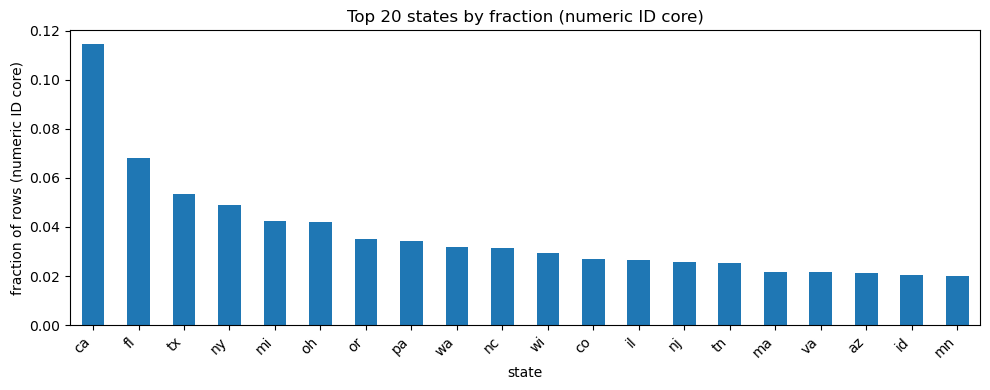

In [121]:
# Cell 18: compute state frequency tables (overall and within numeric ID core)
state_counts = df['state'].value_counts(dropna=False)
state_table = state_counts.to_frame(name='count').reset_index().rename(columns={'index': 'state'})
state_table['fraction'] = state_table['count'] / len(df)
state_table['cum_fraction'] = state_table['fraction'].cumsum()
print("State distribution on full dataset (top 20):")
display(state_table.head(20))

# Restrict to numeric ID core for a cleaner geo analysis
state_counts_id = df.loc[id_mask, 'state'].value_counts(dropna=False)
state_table_id = state_counts_id.to_frame(name='count').reset_index().rename(columns={'index': 'state'})
state_table_id['fraction'] = state_table_id['count'] / id_mask.sum()
state_table_id['cum_fraction'] = state_table_id['fraction'].cumsum()
print("\nState distribution within numeric ID core (top 20):")
display(state_table_id.head(20))

# Plot bar chart for top states by fraction within numeric ID core
top_n_states = 20
fig, ax = plt.subplots(figsize=(10, 4))
state_table_id.head(top_n_states).plot(kind='bar', x='state', y='fraction', ax=ax, legend=False)
ax.set_ylabel('fraction of rows (numeric ID core)')
ax.set_title(f'Top {top_n_states} states by fraction (numeric ID core)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [122]:
# Cell 19: evaluate candidate geographic holdout sets by state
# You can edit geo_candidate_sets to try different combinations of states.
geo_candidate_sets = {
    'CA_only': ['ca'],
    'FL_TX': ['fl', 'tx'],
    'CA_FL_TX': ['ca', 'fl', 'tx'],
}

rows_geo = []
for name, states in geo_candidate_sets.items():
    mask_geo_all = df['state'].isin(states)
    mask_geo_id = mask_geo_all & id_mask
    rows_geo.append({
        'candidate': name,
        'states': ','.join(states),
        'rows_geo_all': int(mask_geo_all.sum()),
        'frac_geo_all': mask_geo_all.mean(),
        'rows_geo_numeric_id': int(mask_geo_id.sum()),
        'frac_geo_numeric_id': mask_geo_id.mean(),
    })

geo_summary = pd.DataFrame(rows_geo)
print("Candidate geographic OOD sizes:")
display(geo_summary)


Candidate geographic OOD sizes:


,candidate,states,rows_geo_all,frac_geo_all,rows_geo_numeric_id,frac_geo_numeric_id
0,CA_only,ca,37529,0.113,33291,0.100
1,FL_TX,"fl,tx",40325,0.122,35321,0.107
2,CA_FL_TX,"ca,fl,tx",77854,0.235,68612,0.207


In [123]:
# Cell 20: define a primary geographic OOD mask for a chosen state set
# Adjust geo_holdout_states based on the summary from Cell 19.
geo_holdout_states = ['fl', 'tx']  # e.g., ['ca'], or ['fl', 'tx'], or ['ca', 'fl', 'tx']

mask_ood_geo_all = df['state'].isin(geo_holdout_states)
mask_ood_geo = mask_ood_geo_all & id_mask  # geographic OOD within numeric ID core
mask_id_no_geo = id_mask & ~mask_ood_geo_all

_summ(mask_ood_geo_all, 'OOD_geo_all (no numeric filter)')
_summ(mask_ood_geo, 'OOD_geo (within numeric ID core)')
_summ(mask_id_no_geo, 'ID_numeric_core_outside_geo_holdout')


OOD_geo_all (no numeric filter): 40325 rows (12.166%)
OOD_geo (within numeric ID core): 35321 rows (10.656%)
ID_numeric_core_outside_geo_holdout: 255657 rows (77.129%)


,subset,year,odometer,mileage_per_year
count,ID_numeric_core_outside_geo_holdout,255657.000,255657.000,255657.000
mean,ID_numeric_core_outside_geo_holdout,2012.954,80897.941,6359.638
std,ID_numeric_core_outside_geo_holdout,5.116,53300.609,3224.010
min,ID_numeric_core_outside_geo_holdout,1999.000,0.000,0.000
1%,ID_numeric_core_outside_geo_holdout,2000.000,24.000,4.000
5%,ID_numeric_core_outside_geo_holdout,2003.000,7017.600,1078.222
10%,ID_numeric_core_outside_geo_holdout,2005.000,14222.000,1979.857
50%,ID_numeric_core_outside_geo_holdout,2014.000,77204.000,6402.125
90%,ID_numeric_core_outside_geo_holdout,2019.000,157474.400,10666.667
95%,ID_numeric_core_outside_geo_holdout,2020.000,175000.000,11732.833


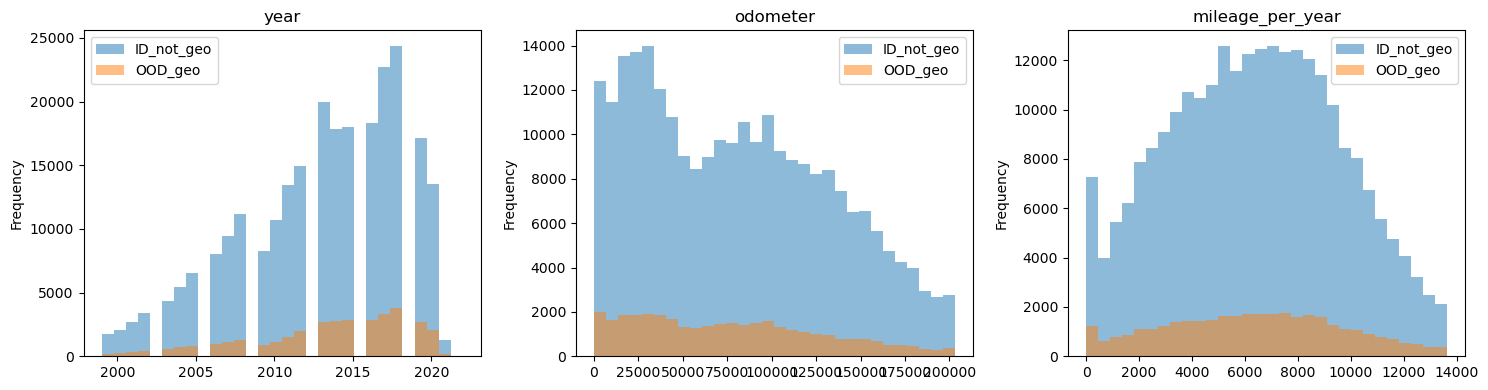

In [124]:
# Cell 21: compare numeric distributions for geographic OOD vs ID numeric core outside held-out states
desc_id_no_geo = describe_subset(mask_id_no_geo, 'ID_numeric_core_outside_geo_holdout')
desc_geo = describe_subset(mask_ood_geo, 'OOD_geo')
display(pd.concat([desc_id_no_geo, desc_geo]))

# Plot histograms for key numeric features comparing ID vs geographic OOD
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    df.loc[mask_id_no_geo, col].plot(kind='hist', bins=30, alpha=0.5,
                                     label='ID_not_geo', ax=ax)
    df.loc[mask_ood_geo, col].plot(kind='hist', bins=30, alpha=0.5,
                                   label='OOD_geo', ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()


In [125]:
# Cell 22: inspect manufacturer, type, and state mix for geographic OOD vs ID outside held-out states
rows_geo_cat = []
for col in ['manufacturer', 'type', 'state']:
    rows_geo_cat.append(top_counts(mask_id_no_geo, 'ID_not_geo', col))
    rows_geo_cat.append(top_counts(mask_ood_geo, 'OOD_geo', col))
cat_summary_geo = pd.concat(rows_geo_cat, ignore_index=True)
display(cat_summary_geo)


,manufacturer,count,fraction,subset,column,type,state
0,ford,38548,0.151,ID_not_geo,manufacturer,NaN,NaN
1,chevrolet,30704,0.120,ID_not_geo,manufacturer,NaN,NaN
2,toyota,20644,0.081,ID_not_geo,manufacturer,NaN,NaN
3,honda,13508,0.053,ID_not_geo,manufacturer,NaN,NaN
4,jeep,11856,0.046,ID_not_geo,manufacturer,NaN,NaN
5,nissan,11626,0.045,ID_not_geo,manufacturer,NaN,NaN
6,bmw,10063,0.039,ID_not_geo,manufacturer,NaN,NaN
7,gmc,9954,0.039,ID_not_geo,manufacturer,NaN,NaN
8,ram,9667,0.038,ID_not_geo,manufacturer,NaN,NaN
9,not_available,7766,0.030,ID_not_geo,manufacturer,NaN,NaN


In [126]:
# Cell 23: show random examples from geographic OOD set for qualitative inspection
n_rows_geo = int(mask_ood_geo.sum())
print(f"Geographic OOD rows (within numeric ID core) for states={geo_holdout_states}: n={n_rows_geo}")
if n_rows_geo > 0:
    cols_to_show = ['region', 'price', 'year', 'manufacturer', 'model', 'odometer',
                    'mileage_per_year', 'condition', 'type', 'state']
    display(df.loc[mask_ood_geo, cols_to_show].sample(min(10, n_rows_geo), random_state=1))


Geographic OOD rows (within numeric ID core) for states=['fl', 'tx']: n=35321


,region,price,year,manufacturer,model,odometer,mileage_per_year,condition,type,state
223540,houston,39993,2017,mercedes-benz,gls,41698,5212.250,not_available,suv,tx
100650,gainesville,24975,2013,not_available,cr-v,44128,3677.333,not_available,suv,fl
96446,gainesville,38590,2020,jaguar,e-pace p250 sport utility,1372,274.400,good,suv,fl
158943,orlando,16977,2013,ford,econoline e150 cargo van,99034,8252.833,good,van,fl
229497,san antonio,34995,2016,ford,f-150,101099,11233.222,not_available,pickup,tx
161119,orlando,44299,2015,ford,f250 super duty crew cab,132728,13272.800,not_available,pickup,fl
216558,ocala,700,2010,toyota,camry,138000,9200.000,not_available,not_available,fl
114910,austin,46995,2017,ford,f-150,48544,6068.000,not_available,truck,tx
73657,space coast,9895,2008,ford,f-150,73038,4296.353,good,truck,fl
189269,jacksonville,1,2019,chevrolet,silverado 1500,80545,13424.167,excellent,truck,fl


## Geographic OOD Summary (from `ood_tails_numeric.ipynb`)

### 1. Goal and approach

- Objective: define an **explicit geographic OOD slice** where:
  - Numeric features (`year`, `odometer`, `mileage_per_year`) remain in-distribution.
  - Manufacturer, type, and overall mix are realistic and similar to ID.
  - The main shift is **location** (state), not extremes in covariates.

- Working within the numeric ID core (no numeric tails), we explored state-based holdouts:
  - `CA_only` – all listings from California.
  - `FL_TX` – all listings from Florida and Texas.
  - `CA_FL_TX` – combined CA, FL, and TX.

### 2. Candidate sizes

Let `N = 331,468` (full dataset). We summarize counts and fractions:

| Candidate  | States    | Rows (all) | % of full | Rows (numeric ID core) | % of numeric ID core |
|------------|-----------|-----------:|----------:|------------------------:|----------------------:|
| CA_only    | ca        | 37,529     | 11.3%     | 33,291                  | 10.0%                 |
| FL_TX      | fl,tx     | 40,325     | 12.2%     | 35,321                  | 10.7%                 |
| CA_FL_TX   | ca,fl,tx  | 77,854     | 23.5%     | 68,612                  | 20.7%                 |

For each candidate we then compared OOD vs ID-all-other-states, restricted to the numeric ID core.

### 3. Numeric distributions

For both CA-only and FL+TX:

- `year`, `odometer`, and `mileage_per_year` in the geographic OOD sets are **nearly identical** to the corresponding ID subset:
  - Medians match (year ≈ 2014, odometer ≈ 77–78k, mpy ≈ 6.3–6.4k).
  - 5th–95th percentiles differ only slightly.
  - Means differ by at most a few hundred miles/year or a couple thousand miles total.
- Histograms for OOD vs ID (for `year`, `odometer`, `mileage_per_year`) show very strong overlap.

Interpretation:

- All candidate geo OODs are **numerically well aligned** with ID, i.e., they do not introduce numeric tails or obvious covariate extremes.
- The OOD signal is primarily **geographic**, which is exactly what we want.

### 4. Category composition

For CA-only and FL+TX:

- Manufacturers:
  - Both OOD sets remain dominated by mainstream brands (Ford, Chevrolet, Toyota, Honda, Nissan, Jeep, etc.).
  - CA skews slightly more toward import/premium brands (BMW, Mercedes, Lexus), while FL+TX skews slightly more toward domestic brands and pickups (Ford, Chevy, Ram).
- Vehicle types:
  - Both OOD sets have realistic mixes of sedans, SUVs, pickups, and trucks.
  - CA has a bit more sedans/hatchbacks/coupes/convertibles; FL+TX has a bit more trucks/pickups, matching local market patterns.

Geographically, CA-only is a single large West-Coast market; FL+TX is a pair of large Sunbelt markets. In all cases, OOD rows are spread over multiple regions within each state (e.g., Houston, Dallas, Miami, Tampa, etc.), not concentrated in a single city.

### 5. Choice of FL+TX over CA-only

We ultimately chose **FL+TX** as the primary geographic OOD set:

- Both CA-only and FL+TX:
  - Are around 10–11% of the numeric ID core (similar OOD size).
  - Have numeric distributions that closely match the non-held-out ID subset.
  - Have realistic, diverse mixes of brands and vehicle types.

- We preferred FL+TX because:
  - It represents **two distinct markets** (Southeast + Texas), reducing the chance that the geo OOD behaviour is overly tied to the quirks of a single state.
  - It emphasizes a slightly more **truck- and pickup-heavy** vehicle mix, which is characteristic of many practical deployment scenarios in those regions.
  - It still remains numerically in-distribution and broadly similar in manufacturer/type mix to the ID data.

Final definition:

- **Geographic OOD (`OOD_geo_fl_tx`)**:
  - All listings with `state ∈ {fl, tx}`, restricted to the numeric ID core (i.e., no numeric tails).
  - Size ≈ 35,321 rows (~10.7% of numeric ID core).
- **Geographic ID subset for comparison**:
  - All other states within the numeric ID core (`state ∉ {fl, tx}`), ≈ 255,657 rows (~77.1% of dataset).

This geo OOD slice complements the numeric-tail and rare-manufacturer OOD sets by providing a clean, realistic domain shift in location without confounding covariate extremes.
